In [218]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression(max_iter=10000)
from sklearn.cluster import KMeans
kmeans=KMeans(max_iter=10000,n_clusters=2)
import warnings
warnings.filterwarnings('ignore')
np.random.seed(16)
df=pd.read_csv(r'A4_question3_data.csv')
df.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


<AxesSubplot:xlabel='Private'>

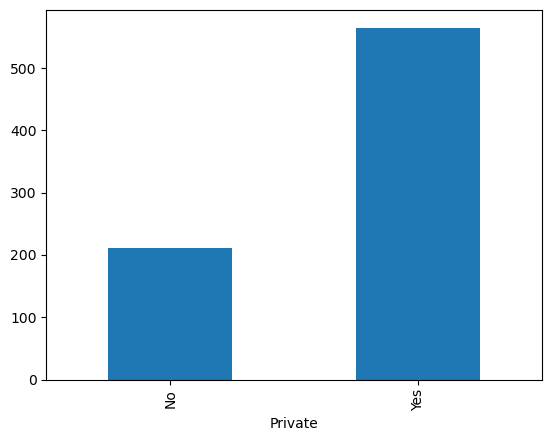

In [219]:
df.groupby('Private').count()['Unnamed: 0'].plot.bar()

In [220]:
#Drop this column as it only gives information about university name and can't be used in prediction
df=df.drop('Unnamed: 0',axis=1)

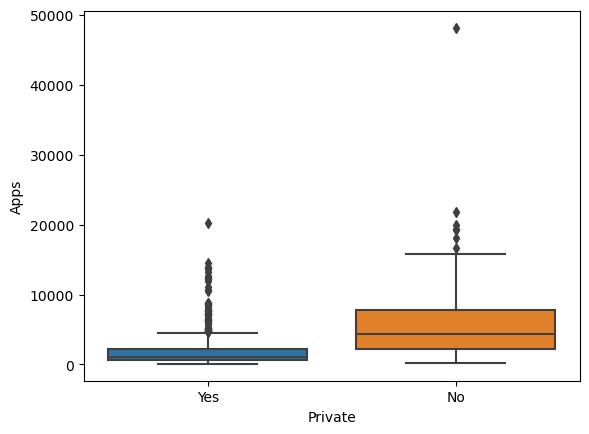

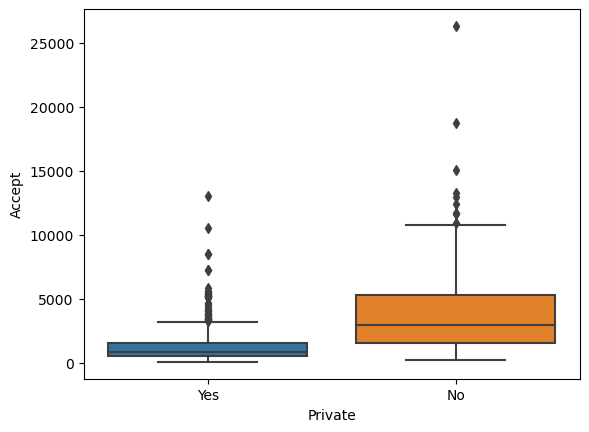

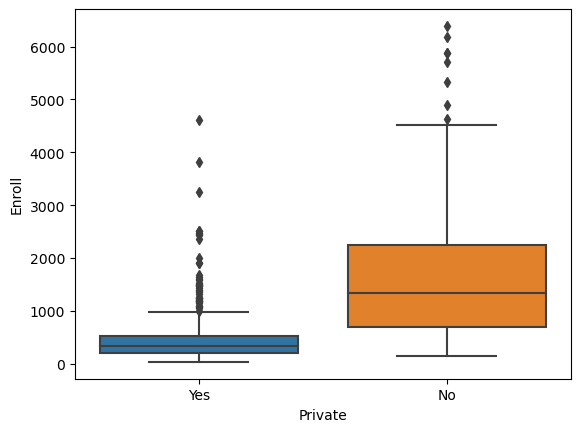

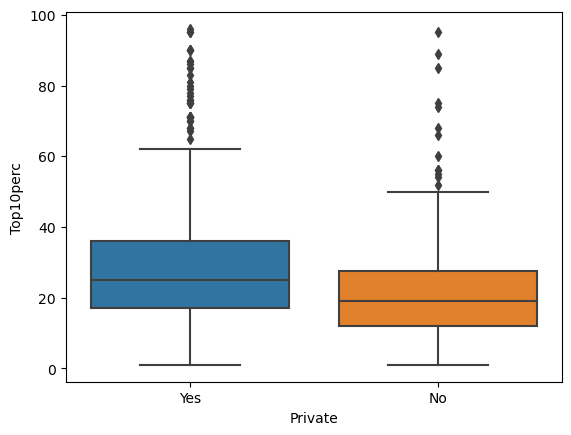

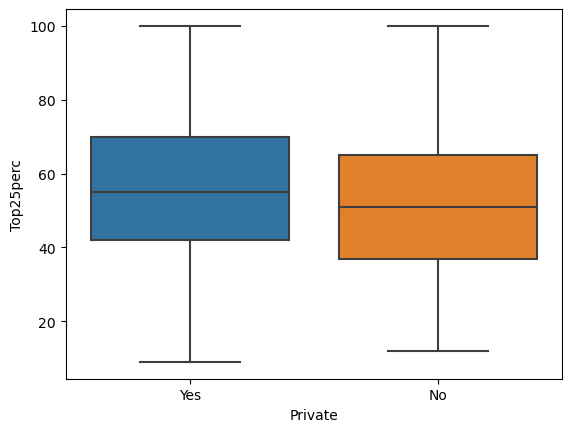

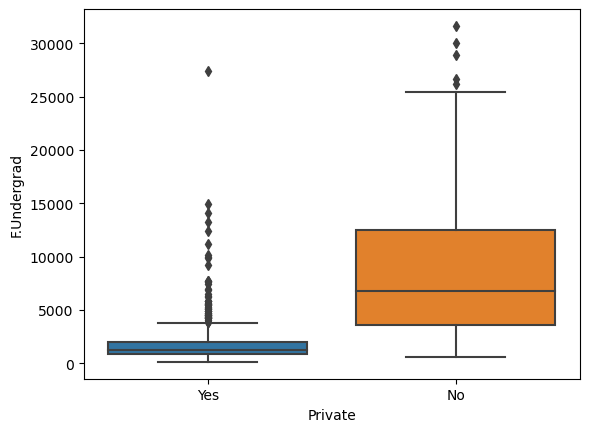

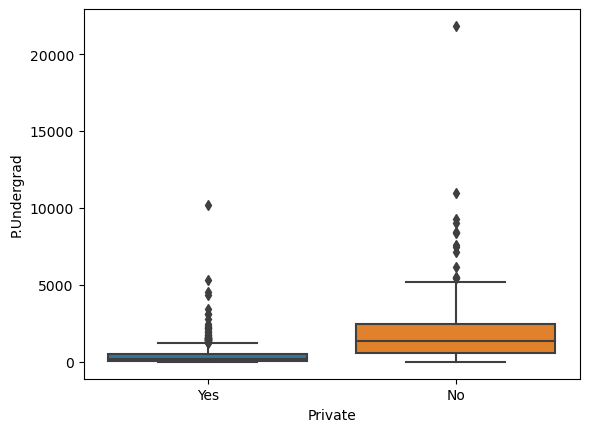

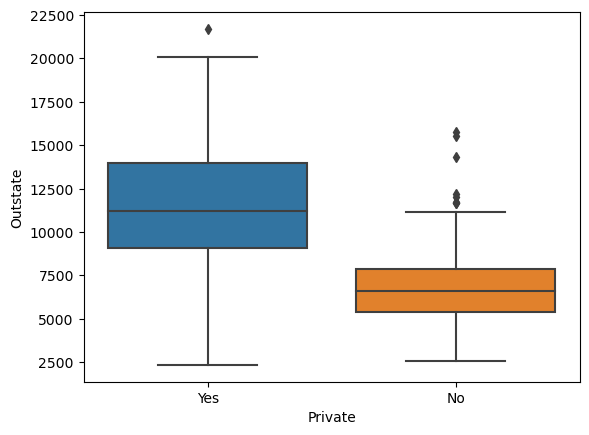

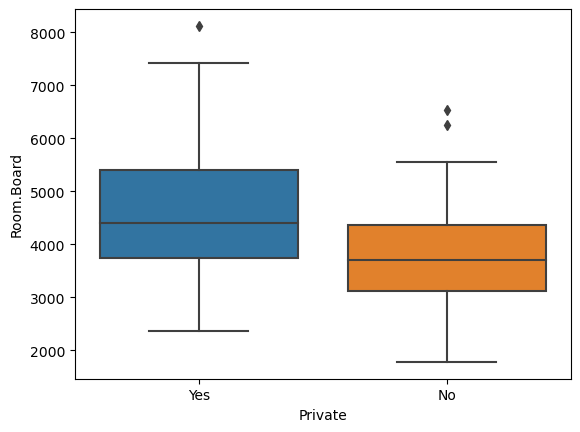

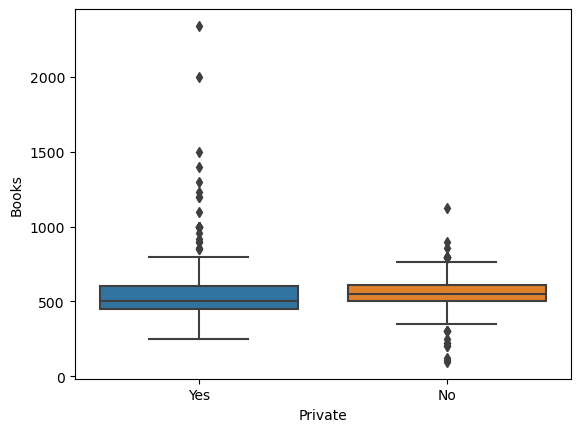

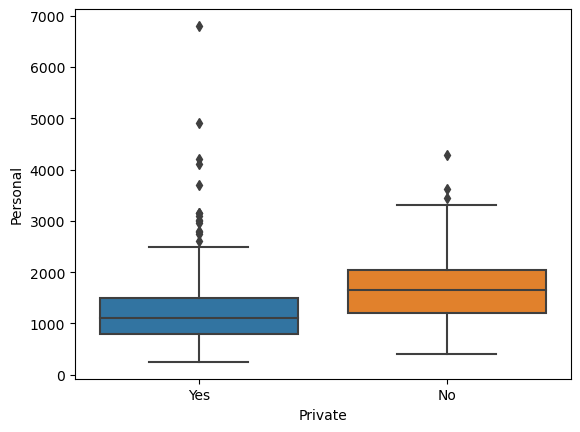

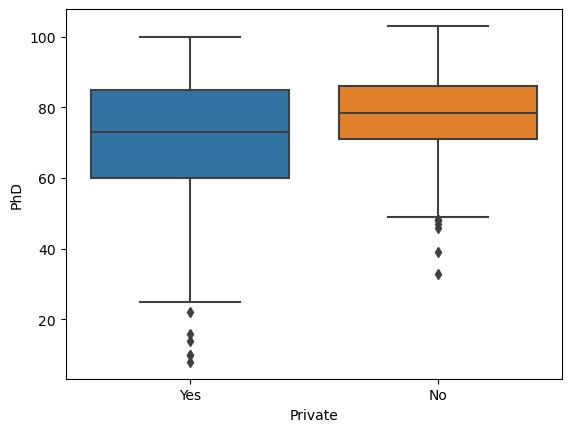

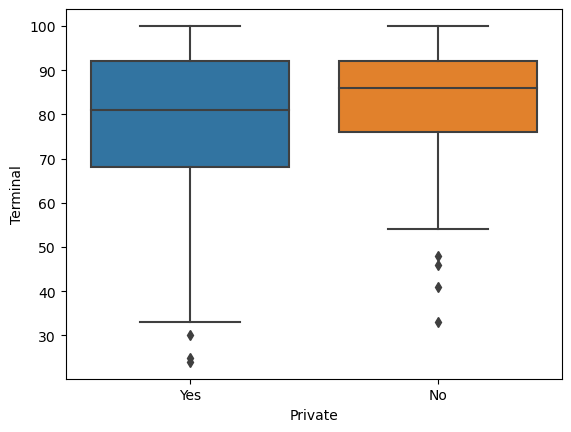

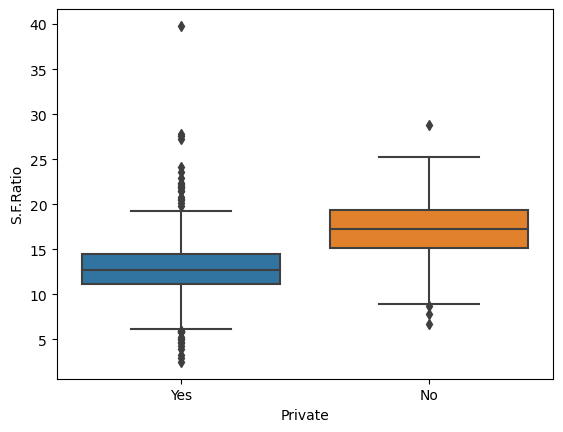

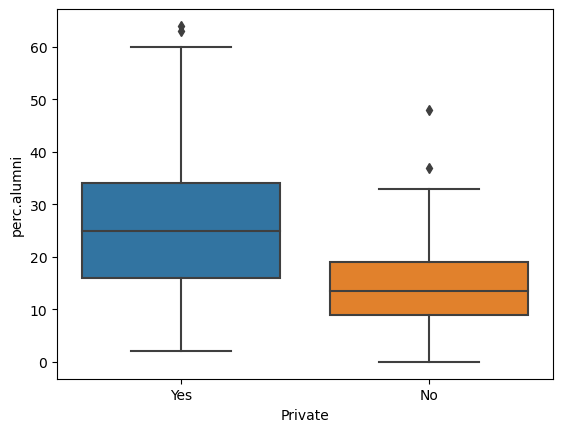

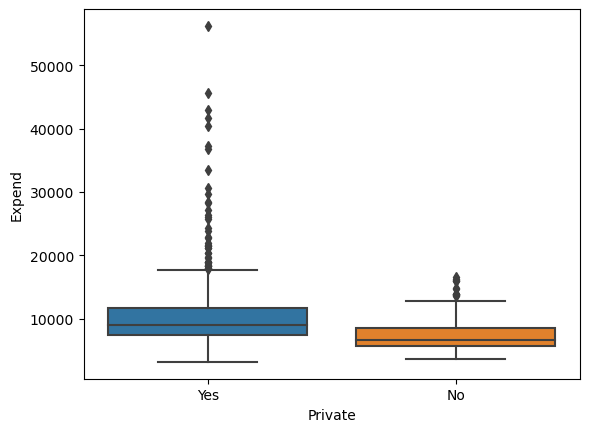

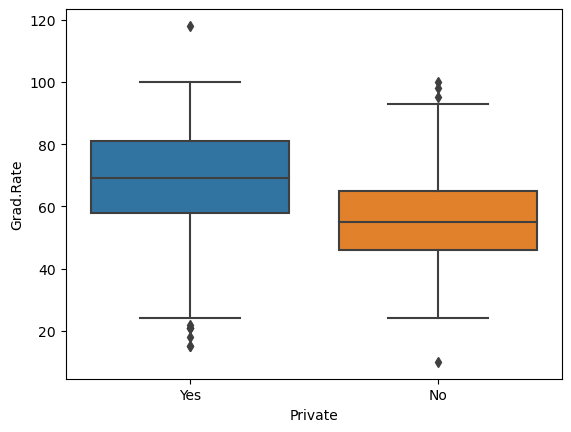

<Figure size 640x480 with 0 Axes>

In [221]:
cols=['Apps','Accept','Enroll','Top10perc','Top25perc','F.Undergrad','P.Undergrad','Outstate','Room.Board','Books','Personal','PhD','Terminal','S.F.Ratio','perc.alumni','Expend','Grad.Rate']
for i in cols:
    sns.boxplot(y=i,x='Private',data=df)
    plt.show()
    plt.clf()


In [222]:
df=df.drop('Top25perc',axis=1)
df=df.drop('Top10perc',axis=1)
df=df.drop('Books',axis=1)
df=df.drop('Terminal',axis=1)
df=df.drop('PhD',axis=1)

In [223]:
df.describe()

,Apps,Accept,Enroll,F.Undergrad,P.Undergrad,Outstate,Room.Board,Personal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,3699.907336,855.298584,10440.669241,4357.526384,1340.642214,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,4850.420531,1522.431887,4023.016484,1096.696416,677.071454,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,139.000000,1.000000,2340.000000,1780.000000,250.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,992.000000,95.000000,7320.000000,3597.000000,850.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,1707.000000,353.000000,9990.000000,4200.000000,1200.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,4005.000000,967.000000,12925.000000,5050.000000,1700.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,31643.000000,21836.000000,21700.000000,8124.000000,6800.000000,39.800000,64.000000,56233.000000,118.00000


In [224]:
#Graduation rate greater than 100 is strange. Hence, we replace it with 100
df['Grad.Rate'][df['Grad.Rate']>100]=100

In [225]:
y=df.pop('Private')
x=df
x_train,x_test, y_train,y_test=train_test_split(x,y,train_size=0.7,random_state=42,stratify=y)
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

In [226]:
#Logistic Regression
print('Logistic regression results: ')
logreg.fit(x_train,y_train)
y_pred=logreg.predict(x_test)
print('Confusion matrix:')
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

Logistic regression results: 
Confusion matrix:
[[ 55   9]
 [  6 164]]
              precision    recall  f1-score   support

          No       0.90      0.86      0.88        64
         Yes       0.95      0.96      0.96       170

    accuracy                           0.94       234
   macro avg       0.92      0.91      0.92       234
weighted avg       0.94      0.94      0.94       234



In [227]:
#K-means clustering
print('K-means clustering results: ')
kmeans.fit(x_train)
y_pred=kmeans.predict(x_test)
y_pred=pd.DataFrame(y_pred,columns=['y_pred'])
print(y_pred['y_pred'].unique())
#Assume 0 stands for Public and 1 stands for Private
y_pred[y_pred==0]='No'
y_pred[y_pred==1]='Yes'
print('Confusion matrix:')
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

K-means clustering results: 
[0 1]
Confusion matrix:
[[ 63   1]
 [ 68 102]]
              precision    recall  f1-score   support

          No       0.48      0.98      0.65        64
         Yes       0.99      0.60      0.75       170

    accuracy                           0.71       234
   macro avg       0.74      0.79      0.70       234
weighted avg       0.85      0.71      0.72       234

